In [1]:
import pandas as pd
import os

# all disease

In [32]:
mapping = {
    'Neoplasms': 'Neoplasms(8)',
    'Diseases of the circulatory system': 'Diseases of the circulatory system(7)',
    'Diseases of the nervous system': 'Diseases of the nervous system(7)',
    'Diseases of the genitourinary system': 'Diseases of the genitourinary system(6)',
    'Mental and behavioural disorders': 'Mental and behavioural disorders(5)',
    'Diseases of the musculoskeletal system and connective tissue': 'Diseases of the musculoskeletal system and connective tissue(3)',
    'Diseases of the respiratory system': 'Diseases of the respiratory system(3)',
    'Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism': 'Diseases of the blood and certain disorders(3)',
    'Endocrine, nutritional and metabolic diseases': 'Endocrine, nutritional and metabolic diseases(2)',
    'Diseases of the digestive system': 'Diseases of the digestive system(2)',
    'Diseases of the skin and subcutaneous tissue': 'Diseases of the skin and subcutaneous tissue(2)'
}

In [33]:
from scipy import stats
import statsmodels.api as sm
import scipy.stats as st
import numpy as np

def all_diff(filtered_df, method1, method2, metric):
    list1 = filtered_df[filtered_df['method']==method1].sort_values(by='disease')[metric].tolist()
    list2 = filtered_df[filtered_df['method']==method2].sort_values(by='disease')[metric].tolist()

    t_stat, p_value = stats.ttest_rel(
        list1,
        list2,
        alternative="greater"   # list1 > list2
    )
    return p_value

def diff_category(filtered_df,method1, method2,metric):
    subdf = filtered_df[(filtered_df['method']==method1)|(filtered_df['method']==method2)][['method','disease',metric,'category']]
    # pivot to wide format
    wide = (
        subdf
        .pivot(index="disease", columns="method", values=metric)
        .dropna()
        .reset_index()
    )

    # name methods explicitly (adjust if needed)
    method1 = wide.columns[1]
    method2 = wide.columns[2]

    wide["diff"] = wide[method1] - wide[method2]
    cat_map = subdf[["disease", "category"]].drop_duplicates()
    wide = wide.merge(cat_map, on="disease")

    y = wide["diff"]
    X = pd.DataFrame({"const": 1.0}, index=wide.index)   # explicit intercept name

    ols = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": wide["category"]}
    )

    beta = ols.params["const"]
    se   = ols.bse["const"]

    z = beta / se
    p_one_sided = 1 - st.norm.cdf(z)   # H1: beta > 0

    prop_diseases = (wide["diff"] > 0).mean()

    cat_means = (wide.groupby("category", observed=True)["diff"].mean())

    prop_categories = (cat_means > 0).mean()

    return round(prop_diseases,2),round(prop_categories,2),beta,p_one_sided

def paired_cluster_test(df, m1, m2, metric):
    wide = (
        df[df["method"].isin([m1, m2])]
        .pivot_table(index="disease", columns="method", values=metric, aggfunc="mean")
        .dropna()
        .reset_index()
    )

    wide["diff"] = wide[m1] - wide[m2]

    cat_map = df[["disease", "category"]].drop_duplicates()
    wide = wide.merge(cat_map, on="disease")

    X = np.ones((len(wide), 1))
    ols = sm.OLS(wide["diff"], X).fit(
        cov_type="cluster",
        cov_kwds={"groups": wide["category"]}
    )

    beta = float(ols.params.iloc[0])
    se = float(ols.bse.iloc[0])

    z = beta / se
    p_one_sided = 1 - st.norm.cdf(z)

    return beta, se, p_one_sided


In [39]:
statics = []

### OCC

In [34]:
file1 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_oob.xlsx'
file2 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_occ_all.xlsx'
file3 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_nn_oob_all.xlsx'

df_svm = pd.read_excel(file1, sheet_name='disease')
df_occ = pd.read_excel(file2, sheet_name='disease')
df_nn = pd.read_excel(file3, sheet_name='disease')

df_occ.loc[df_occ['method'] == 'occ', 'method'] = 'occ-svm'
df_nn = df_nn.replace('DL_', '', regex=True) 

df_svm['category'] = df_svm['category'].replace(mapping)
df_occ['category'] = df_occ['category'].replace(mapping)
df_nn['category'] = df_nn['category'].replace(mapping)

df_svm = df_svm[df_svm['para']=='uniport_ppi_2019']
df_svm['method'] = 'Bagging-SVMs'
df_nn = df_nn[df_nn['para']=='uniport_ppi_2019']
df_nn['method'] = 'Bagging-DNNs'

filtered_df = pd.concat([df_svm, df_nn, df_occ], ignore_index=True)

# Compute mean AUROC per category
cat_order = (
    filtered_df.groupby("category")["auroc"]
    .mean()
    .sort_values(ascending=False)
)

# Sort the whole DataFrame by that category order
filtered_df["category"] = pd.Categorical(
    filtered_df["category"],
    categories=cat_order.index,
    ordered=True
)

filtered_df = filtered_df.sort_values("category").reset_index(drop=True)

In [40]:
for pair in [['Bagging-SVMs', 'occ-svm'],['Bagging-DNNs', 'occ_deep_svd']]:
    for metric in ['auroc', 'bedroc_1', 'bedroc_5','bedroc_10', 'bedroc_30']:
        single_stat = ['occ_vs_bagging',pair[0],pair[1],metric]
        single_stat.extend(paired_cluster_test(filtered_df, pair[0], pair[1], metric))
        statics.append(single_stat)

In [9]:
for metric in ['auroc', 'bedroc_1', 'bedroc_5',
       'bedroc_10', 'bedroc_30']:
    # print(all_diff(filtered_df, 'Bagging-SVMs', 'occ-svm', metric),all_diff(filtered_df, 'Bagging-DNNs', 'occ_deep_svd', metric))
    print(diff_category(filtered_df, 'Bagging-SVMs', 'occ-svm', metric),diff_category(filtered_df, 'Bagging-DNNs', 'occ_deep_svd', metric))


(0.73, 0.91, 0.08652083333333337, 3.5143113620295097e-06) (0.56, 0.82, 0.0333125, 0.07235749123609558)
(0.44, 0.82, 0.07797916666666671, 0.003827219369313628) (0.31, 0.27, -0.012875000000000003, 0.6861723283355842)
(0.73, 0.91, 0.13250000000000006, 0.0006279395028503387) (0.52, 0.82, 0.012249999999999997, 0.34240934140635015)
(0.77, 0.91, 0.15925000000000006, 2.5367479220217426e-05) (0.52, 0.82, 0.03695833333333335, 0.11544560040471608)
(0.79, 1.0, 0.16456250000000008, 1.0107770176404074e-10) (0.54, 0.73, 0.0547916666666667, 0.036753591300274446)


### feature

In [75]:
file1 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_oob.xlsx'
file2 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_rf_all.xlsx'
file3 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_nn_oob_all.xlsx'

df_svm = pd.read_excel(file1, sheet_name='disease')
df_rf = pd.read_excel(file2, sheet_name='disease')
df_nn = pd.read_excel(file3, sheet_name='disease')

def process_df_occ(df_sum):
    feature_keywords = [
        'uniport_ppi_2019', 'ppi_2019_dw_40', 'diffusion_2019',
        'uniport_bio', 'uniport_esm', 'uniport_seq']
    df_sum = df_sum.replace('linear_', 'mid_linear_', regex=True)    
    df_sum = df_sum.replace('geo_', 'mid_geo_', regex=True)
    df_sum = df_sum.replace('DL_', '', regex=True)
    df_sum = df_sum.replace('RF_', '', regex=True)
    df_sum = df_sum.replace('diffusion_2019_2', 'diffusion_2019', regex=True)
    df_feature_sum = df_sum[df_sum['para'].isin(feature_keywords)].copy()

    mapping = {
        'uniport_ppi_2019': 'ppi_emb_n2v',
        'ppi_2019_dw_40':'ppi_emb_dw',
        'diffusion_2019': 'ppi_emb_df',
        'uniport_bio': 'literature_emb',
        'uniport_esm': 'seq_emb_esm',
        'uniport_seq':'seq_emb_port'}
    df_feature_sum['para'] = df_feature_sum['para'].replace(mapping)
    return df_feature_sum
    
df1 = process_df_occ(df_svm)
df2 = process_df_occ(df_nn)
df3 = process_df_occ(df_rf)

df1['method'] = 'SVMs'
df2['method'] = 'DNNs'
df3['method'] = 'RFs'

filtered_df = pd.concat([df1, df2, df3], ignore_index=True)


In [49]:
for modle_type in filtered_df['method'].unique():
    df = filtered_df[filtered_df['method']==modle_type].copy()
    for metric in ['auroc', 'bedroc_1', 'bedroc_5','bedroc_10', 'bedroc_30']:
        df['method'] = df['para']
        df['method'] = df['method'].str.split('_').str[0]
        df_type = (
            df
            .groupby(["disease", "category", "method"], observed=True)[metric]
            .mean()
            .reset_index()
        )
        for pair in [["ppi", "literature"],["ppi", "seq"],["literature", "seq"]]:
            single_stat = [modle_type+'_features',pair[0],pair[1],metric]
            single_stat.extend(paired_cluster_test(df_type, pair[0], pair[1], metric))
            statics.append(single_stat)

### bio_sim related

In [76]:
bio_sim = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/bio_sim_all.csv')

In [77]:
select_features = ['ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df', 'literature_emb',
       'seq_emb_esm', 'seq_emb_port']
select_models = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred']
name_map = {
    'df_gnn_occsvm_pred': 'SVMs',
    '2019_nn_all_pred': 'DNNs',
    '2019_rf_renamed_pred': 'RFs'}

In [78]:
bio_sim = bio_sim[bio_sim['feature'].isin(select_features)]
bio_sim = bio_sim[bio_sim['method'].isin(select_models)]
bio_sim['method'] = bio_sim['method'].map(name_map)

In [79]:
bio_sim['para'] = bio_sim['feature']

In [18]:
filtered_df.columns

Index(['method', 'para', 'top_recall_25', 'top_recall_300', 'top_recall_10%',
       'top_recall_30%', 'auroc', 'rank_ratio', 'bedroc_1', 'bedroc_5',
       'bedroc_10', 'bedroc_30', 'weights_1', 'weights_2', 'weights_3',
       'disease', 'category', 'feature', 'cutoff_0.0%', 'cutoff_0.06%',
       'cutoff_0.11%', 'cutoff_0.17%', 'cutoff_0.22%', 'cutoff_0.28%',
       'cutoff_0.33%', 'cutoff_0.39%', 'cutoff_0.44%', 'cutoff_0.5%'],
      dtype='object')

In [80]:
filtered_df = filtered_df.merge(
    bio_sim,
    how="inner",
    on=["method", "para", "disease"]
)

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

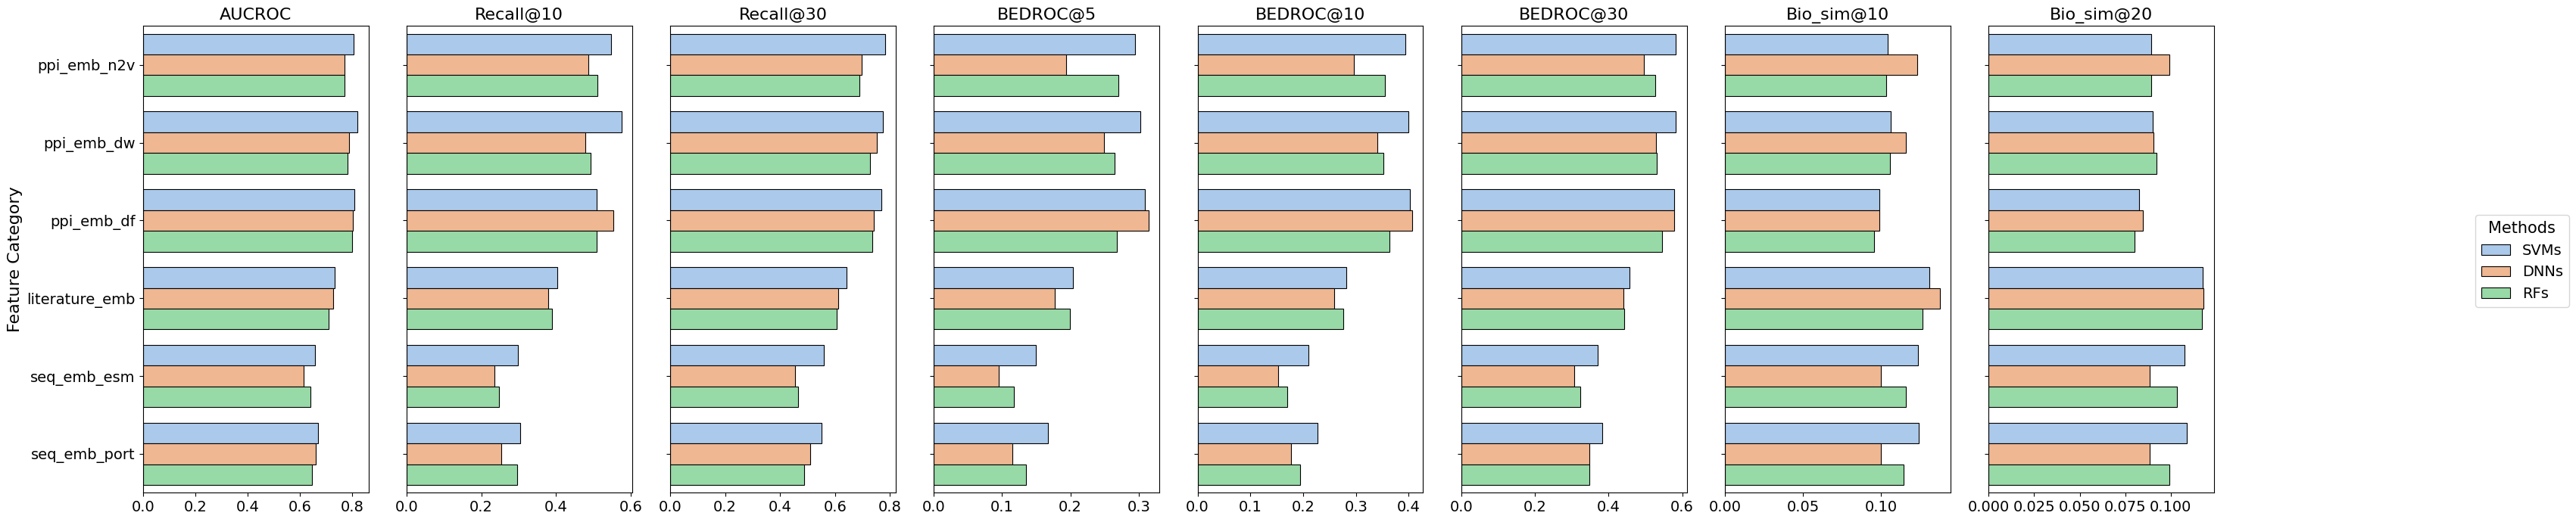

In [84]:
metric_names = ['AUCROC', 'Recall@10', 'Recall@30',
                'BEDROC@5', 'BEDROC@10', 'BEDROC@30',
                'Bio_sim@10','Bio_sim@20']

metrics = ['auroc', 'top_recall_10%', 'top_recall_30%',
           'bedroc_5', 'bedroc_10', 'bedroc_30',
           'cutoff_0.11%', 'cutoff_0.22%']

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(metrics),   # make consistent with metric list
    figsize=(4 * len(metrics), 7),
    sharey=True
)

for ax, metric, metric_name in zip(axes, metrics, metric_names):

    sns.barplot(
        data=filtered_df,
        y='para',
        x=metric,
        hue='method',
        palette='pastel',
        errorbar=None,
        edgecolor='black',
        linewidth=0.8,
        ax=ax
    )

    ax.set_title(metric_name, fontsize=16)

    ax.margins(x=0.05)

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.set_xlabel('')
    ax.set_ylabel('')

    if ax.get_legend() is not None:
        ax.get_legend().remove()

# shared y-label
axes[0].set_ylabel('Feature Category', fontsize=16)

# ---- single global legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Methods',
    title_fontsize=15,
    fontsize=14,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left'
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


DNNs literature_emb top_recall_10% cutoff_0.06% 0.1915149059524056 0.00015957041724807335


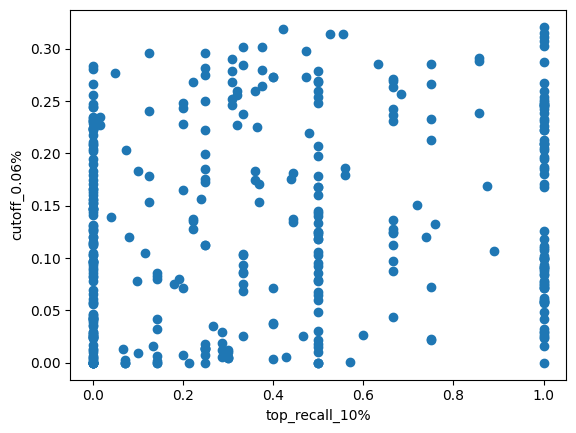

DNNs literature_emb bedroc_5 cutoff_0.06% 0.1795711129486255 0.00040596602704660384


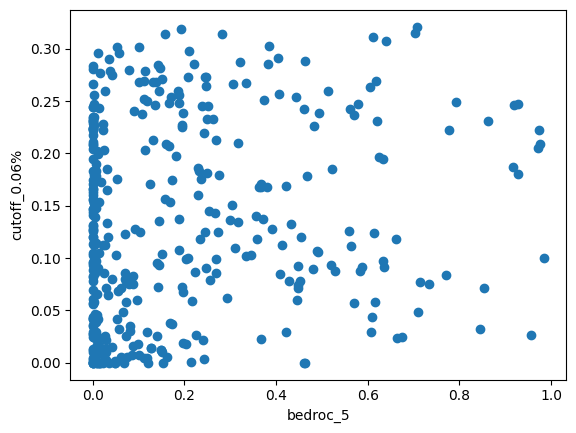

DNNs seq_emb_esm top_recall_10% cutoff_0.06% 0.19899866285982398 8.630359843709913e-05


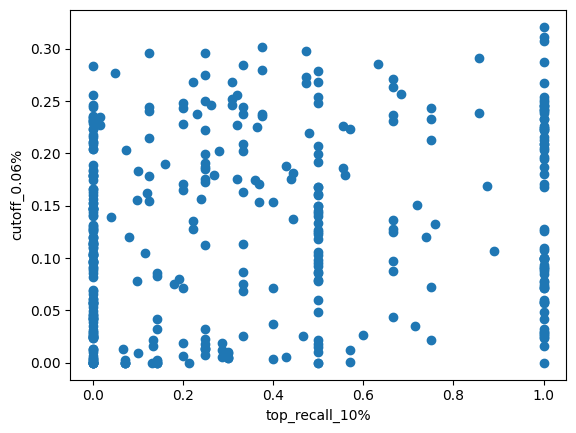

DNNs seq_emb_esm top_recall_10% cutoff_0.11% 0.16974492071837693 0.0008385948310118303


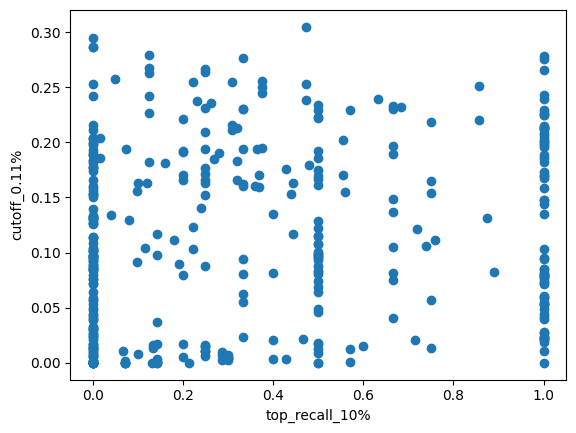

DNNs seq_emb_esm bedroc_5 cutoff_0.06% 0.17385695115546335 0.0006219094577697444


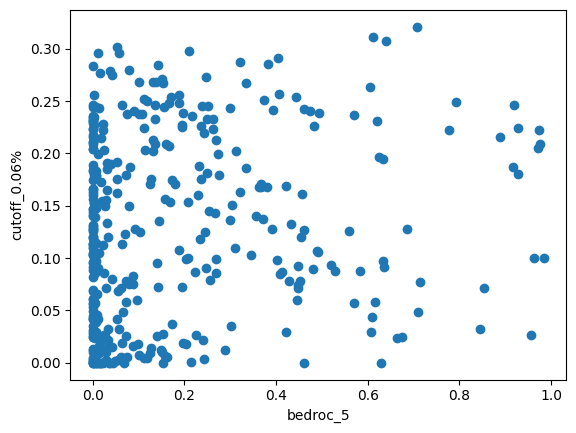

DNNs seq_emb_port top_recall_10% cutoff_0.06% 0.18310889638480707 0.00030971975793851736


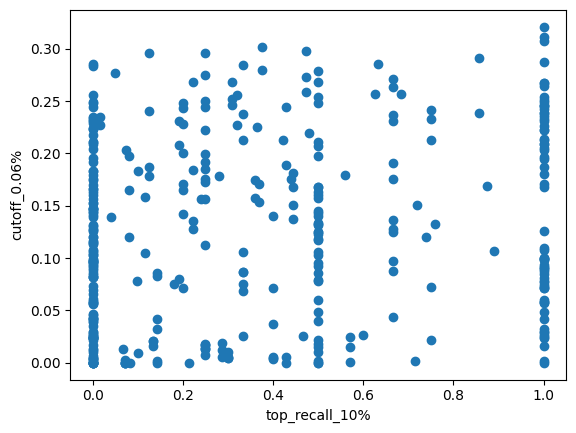

DNNs seq_emb_port bedroc_5 cutoff_0.06% 0.17194169860332006 0.0007154116049465599


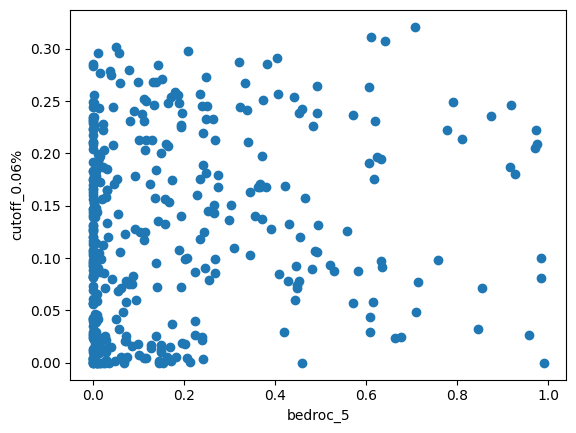

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

corr_results = []
for model in filtered_df['method'].unique():
    for feature in filtered_df['para'].unique():
        subdf = filtered_df[(filtered_df['method']==model)|(filtered_df['para']==feature)]
        for metric in ['auroc', 'top_recall_10%', 'top_recall_30%',
                'bedroc_5', 'bedroc_10', 'bedroc_30']:
            for cutoff in ['cutoff_0.06%',
       'cutoff_0.11%', 'cutoff_0.17%', 'cutoff_0.22%', 'cutoff_0.28%',
       'cutoff_0.33%', 'cutoff_0.39%', 'cutoff_0.44%', 'cutoff_0.5%']:
                r, p = spearmanr(subdf[metric], subdf[cutoff])
                if p < 0.001:
                    print(model, feature, metric, cutoff, r, p)
                    corr_results.append([model, feature, metric, cutoff, r, p])

                    plt.scatter(subdf[metric], subdf[cutoff])
                    plt.xlabel(metric)
                    plt.ylabel(cutoff)
                    plt.show()


In [ ]:
corr_df = pd.DataFrame(corr_results)
corr_df

,0,1,2,3,4,5
0,DNNs,literature_emb,top_recall_10%,cutoff_0.06%,0.191515,0.000160
1,DNNs,literature_emb,bedroc_5,cutoff_0.06%,0.179571,0.000406
2,DNNs,seq_emb_esm,top_recall_10%,cutoff_0.06%,0.198999,0.000086
3,DNNs,seq_emb_esm,top_recall_10%,cutoff_0.11%,0.169745,0.000839
4,DNNs,seq_emb_esm,bedroc_5,cutoff_0.06%,0.173857,0.000622
5,DNNs,seq_emb_port,top_recall_10%,cutoff_0.06%,0.183109,0.000310
6,DNNs,seq_emb_port,bedroc_5,cutoff_0.06%,0.171942,0.000715


In [45]:
def three_diff(filtered_df,modle_type,metric):
    df = filtered_df[filtered_df['method']==modle_type].copy()
    df['method'] = df['para']
    df['type'] = df['method'].str.split('_').str[0]
    df_type = (
        df
        .groupby(["disease", "category", "type"], observed=True)["auroc"]
        .mean()
        .reset_index()
    )

    beta_AB, se_AB, p_AB = paired_cluster_test(df_type, "ppi", "literature",metric)
    beta_AC, se_AC, p_AC = paired_cluster_test(df_type, "ppi", "seq",metric)
    beta_BC, se_BC, p_BC = paired_cluster_test(df_type, "literature", "seq",metric)

    print("A vs B:", beta_AB, se_AB, p_AB)
    print("A vs C:", beta_AC, se_AC, p_AC)
    print("B vs C:", beta_BC, se_BC, p_BC)

    wide_types = (
    df_type
    .pivot(index="disease", columns="type", values="auroc"))

    wins = wide_types.idxmax(axis=1)
    win_rate = wins.value_counts(normalize=True)

    print(win_rate)

    cat_means = (
        df_type
        .groupby(["category", "type"], observed=True)["auroc"]
        .mean()
        .reset_index()
    )

    cat_winners = cat_means.loc[
        cat_means.groupby("category")["auroc"].idxmax()
    ]

    print(cat_winners["type"].value_counts())


In [ ]:
three_diff(filtered_df,'SVMs','auroc')

A vs B: 0.07719444444444447 0.03503968735560076 0.013795349678417446
A vs C: 0.1480069444444445 0.018480640967654116 5.551115123125783e-16
B vs C: 0.07081250000000003 0.03609224632077799 0.024882028059773242
ppi           0.583333
literature    0.250000
seq           0.166667
Name: proportion, dtype: float64
type
ppi           8
literature    2
seq           1
Name: count, dtype: int64


/tmp/ipykernel_205217/907598457.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = float(ols.params[0])
/tmp/ipykernel_205217/907598457.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  se = float(ols.bse[0])
/tmp/ipykernel_205217/907598457.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = float(ols.params[0])
/tmp/ipykernel_205217/907598457.py:33: FutureWarning: Series.__getitem__ treating keys as positions is

In [16]:
three_diff(filtered_df,'DNNs')

A vs B: 0.0599513888888889 0.02446230931428705 0.007127635287502043
A vs C: 0.14944097222222227 0.022385220802411218 1.2287948436551233e-11
B vs C: 0.08948958333333337 0.03439002599320392 0.004631446702740183
ppi           0.604167
literature    0.250000
seq           0.145833
Name: proportion, dtype: float64
type
ppi           8
literature    3
Name: count, dtype: int64


/tmp/ipykernel_205217/907598457.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = float(ols.params[0])
/tmp/ipykernel_205217/907598457.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  se = float(ols.bse[0])
/tmp/ipykernel_205217/907598457.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = float(ols.params[0])
/tmp/ipykernel_205217/907598457.py:33: FutureWarning: Series.__getitem__ treating keys as positions is

In [17]:
three_diff(filtered_df,'RFs')

A vs B: 0.0721156462585034 0.02746936997976633 0.004328489477078645
A vs C: 0.14399319727891155 0.0249890062812033 4.149705468137199e-09
B vs C: 0.07187755102040816 0.038519259687312665 0.031019570517286987
ppi           0.530612
literature    0.306122
seq           0.163265
Name: proportion, dtype: float64
type
ppi           10
literature     1
Name: count, dtype: int64


/tmp/ipykernel_205217/907598457.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = float(ols.params[0])
/tmp/ipykernel_205217/907598457.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  se = float(ols.bse[0])
/tmp/ipykernel_205217/907598457.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = float(ols.params[0])
/tmp/ipykernel_205217/907598457.py:33: FutureWarning: Series.__getitem__ treating keys as positions is

In [7]:
subdf['para'].unique()

array(['seq_emb_port', 'seq_emb_esm', 'literature_emb', 'ppi_emb_df',
       'ppi_emb_dw', 'ppi_emb_n2v'], dtype=object)

/tmp/ipykernel_2085485/1872314411.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


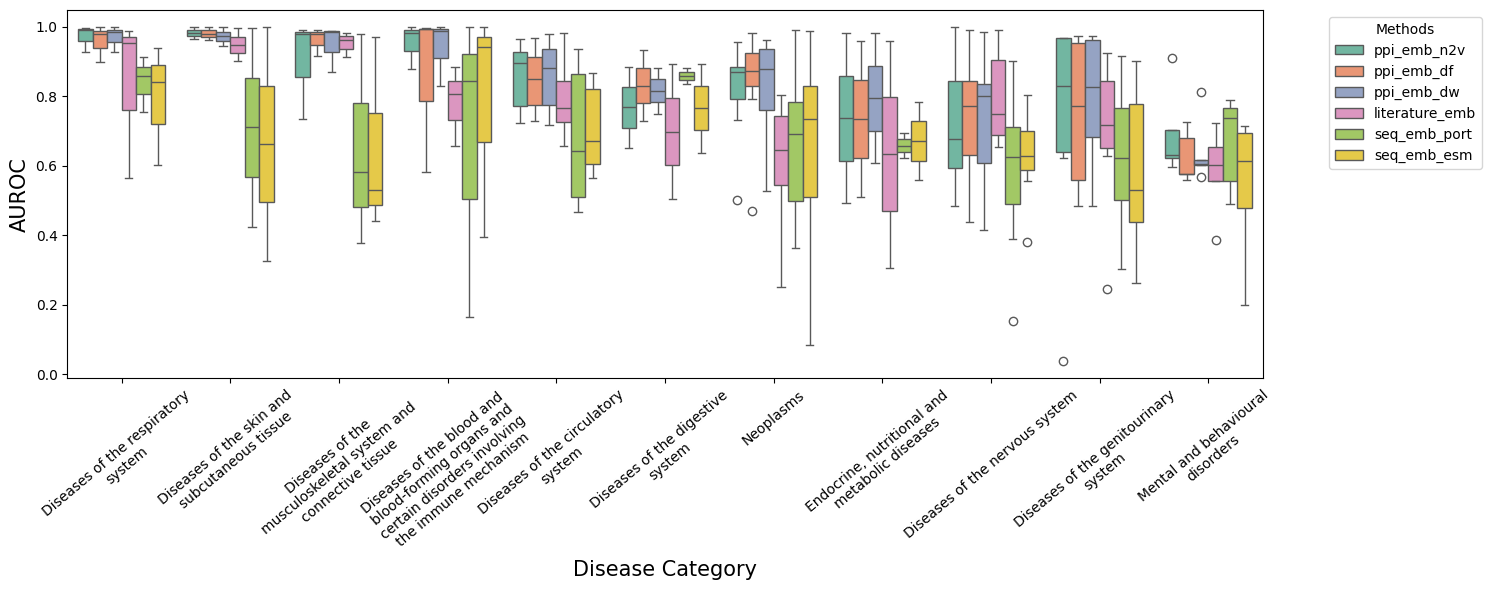

In [8]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(15, 6))

subdf = filtered_df[filtered_df['method']=='SVMs'].copy()

# ---- Define desired para order ----
para_order = [
    'ppi_emb_n2v',
    'ppi_emb_df',
    'ppi_emb_dw',
    'literature_emb',
    'seq_emb_port',
    'seq_emb_esm'
]

subdf['para'] = pd.Categorical(
    subdf['para'],
    categories=para_order,
    ordered=True
)

# ---- Compute mean AUROC per category ----
cat_order = (
    subdf.groupby("category")["auroc"]
    .mean()
    .sort_values(ascending=False)
)

# ---- Sort category axis ----
subdf["category"] = pd.Categorical(
    subdf["category"],
    categories=cat_order.index,
    ordered=True
)

subdf = subdf.sort_values(["category", "para"]).reset_index(drop=True)

# ---- Plot ----
ax = sns.boxplot(
    data=subdf,
    x='category',
    y='auroc',
    hue='para',
    hue_order=para_order,   # enforce legend + box order
    palette='Set2',
)

# ---- Wrap & rotate x labels ----
labels = ax.get_xticklabels()
new_labels = [textwrap.fill(lbl.get_text(), width=30) for lbl in labels]
ax.set_xticklabels(new_labels, rotation=40, ha='center')

# ---- Legend ----
plt.legend(title='Methods',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

# ---- Labels ----
plt.xlabel('Disease Category', fontsize=15)
plt.ylabel('AUROC', fontsize=15)

plt.tight_layout()
plt.show()


### models

In [51]:
file1 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_oob.xlsx'
file2 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_rf_all.xlsx'
file3 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_nn_oob_all.xlsx'
file4 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gnn.xlsx'
file5 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_mf_bag_2.xlsx'

def read_process(filepath):
    df = pd.read_excel(filepath, sheet_name='disease')

    df['category'] = df['category'].replace(mapping)

    df = df.replace('DL_', '', regex=True)
    df = df.replace('RF_', '', regex=True)

    # Fix: detect 'gcn' in para correctly
    mask = df['para'].astype(str).str.contains('gcn|sage', case=False, na=False)
    if mask.any():
        df.loc[mask, 'method'] = df.loc[mask, 'para']
        df.loc[mask, 'para'] = 'uniport_ppi_2019'

    df = df[df['para'] == 'uniport_ppi_2019']
    return df


df_svm = read_process(file1)
df_rf = read_process(file2)
df_nn = read_process(file3)
df_gnn = read_process(file4)
df_mf = read_process(file5)
df_mf['method'] = 'MF'
df_svm['method'] = 'SVMs'
df_rf['method'] = 'RFs'
df_nn['method'] = 'DNNs'

filtered_df = pd.concat([df_svm, df_nn, df_rf,df_gnn,df_mf], ignore_index=True)

# Compute mean AUROC per category
cat_order = (
    filtered_df.groupby("category")["auroc"]
    .mean()
    .sort_values(ascending=False)
)

# Sort the whole DataFrame by that category order
filtered_df["category"] = pd.Categorical(
    filtered_df["category"],
    categories=cat_order.index,
    ordered=True
)

filtered_df = filtered_df.sort_values("category").reset_index(drop=True)


In [57]:
len(statics)

85

In [56]:
for metric in ['auroc', 'top_recall_10%', 'top_recall_30%',
           'bedroc_5', 'bedroc_10', 'bedroc_30']:
    wide = (
        filtered_df.pivot_table(index="disease", columns="method", values=metric, aggfunc="mean")
        .dropna()
    )

    from scipy.stats import friedmanchisquare

    stat, p_global = friedmanchisquare(*[wide[m] for m in wide.columns])
    print("Global p-value:", p_global)

    mean_auroc = wide.mean().sort_values(ascending=False)
    best_method = mean_auroc.index[0]
    print("Candidate best:", best_method)

    methods = wide.columns.tolist()
    others = [m for m in methods if m != best_method]

    results = []
    for m in others:
        beta, se, p = paired_cluster_test(filtered_df, best_method, m, metric)
        statics.append(['models',best_method,m,metric,beta, se, p])
        results.append({
            "comparison": f"{best_method} vs {m}",
            "mean_diff": beta,
            "se": se,
            "p_one_sided": p
        })

    res_df = pd.DataFrame(results)
    print(res_df)


Global p-value: 1.1093847962786012e-05
Candidate best: sage
     comparison  mean_diff        se  p_one_sided
0  sage vs DNNs   0.034766  0.010553     0.000493
1    sage vs MF   0.015128  0.015605     0.166172
2   sage vs RFs   0.037617  0.029938     0.104467
3  sage vs SVMs   0.001319  0.012359     0.457499
4   sage vs gcn   0.024766  0.012539     0.024128
Global p-value: 0.1739745543386639
Candidate best: SVMs
     comparison  mean_diff        se  p_one_sided
0  SVMs vs DNNs   0.060938  0.039712     0.062456
1    SVMs vs MF   0.052583  0.050499     0.148872
2   SVMs vs RFs   0.036125  0.030641     0.119202
3   SVMs vs gcn   0.061681  0.052477     0.119920
4  SVMs vs sage   0.028638  0.055193     0.301924
Global p-value: 0.014225950683676518
Candidate best: SVMs
     comparison  mean_diff        se  p_one_sided
0  SVMs vs DNNs   0.084396  0.031594     0.003778
1    SVMs vs MF   0.026104  0.022577     0.123795
2   SVMs vs RFs   0.093354  0.050857     0.033208
3   SVMs vs gcn   0.061064

/tmp/ipykernel_205217/742550181.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


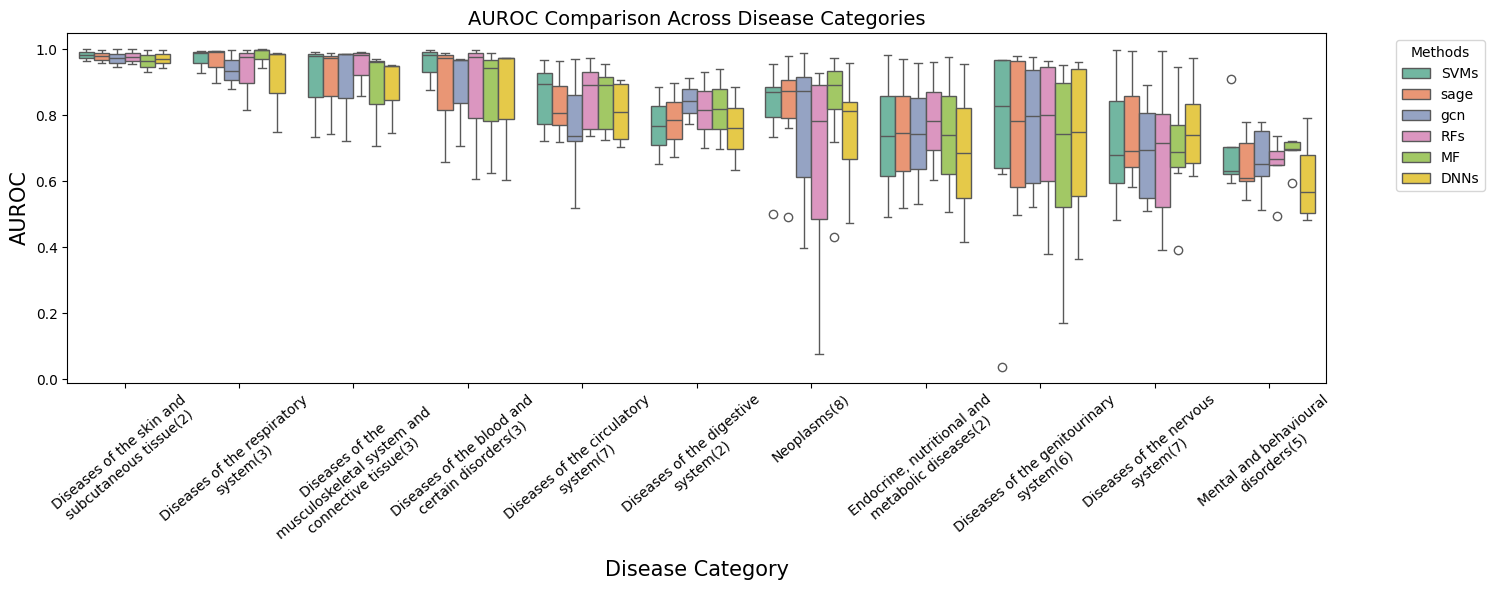

In [39]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

ax = sns.boxplot(
    data=filtered_df,
    x='category',
    y='auroc',
    hue='method',
    palette='Set2',
)

# ----- Wrap & rotate x labels -----
labels = ax.get_xticklabels()
new_labels = [textwrap.fill(lbl.get_text(), width=30) for lbl in labels]

ax.set_xticklabels(new_labels, rotation=40, ha='center')

# ----- Manual legend (stable) -----
handles, leg_labels = ax.get_legend_handles_labels()
plt.legend(handles, leg_labels, title='Methods',
           bbox_to_anchor=(1.05, 1), loc='upper left')

# ----- Titles -----
plt.title('AUROC Comparison Across Disease Categories', fontsize=14)
plt.xlabel('Disease Category', fontsize=15)
plt.ylabel('AUROC', fontsize=15)

plt.tight_layout()
plt.show()


## fusion

In [58]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/'
folders = ['2019_df_oob', '2019_nn_oob_all']
# folders = ['2019_df_oob']

# Initialize an empty list to collect data
fusion_sum_list = []

# Define the feature keywords you want to keep
feature_keywords = ['early','mid','later']

for folder in folders:
    file_path = os.path.join(root, folder + '.xlsx')

    df_sum = pd.read_excel(file_path, sheet_name='disease')
    if 'linear_fused' in df_sum['para'].values:
        mids = ['linear_fused', 'linear_fused_ppi', 'geo_fused', 'geo_fused_ppi']
        df_sum.loc[df_sum['para'].isin(mids), 'para'] = df_sum['para'] + '_mid'
        df_sum['para'] = df_sum['para'].replace('diffusion_2019_2', 'diffusion_2019')
    rows = [rowname for rowname in df_sum['para'].unique() if any(kw in rowname for kw in feature_keywords)]

    df_feature_sum = df_sum[df_sum['para'].isin(rows)].copy()

    df_feature_sum['model'] = folder
    df_feature_sum['category'] = df_feature_sum['category'].replace(mapping)
    fusion_sum_list.append(df_feature_sum)

# Combine all into a single DataFrame
fusion_sum_list = pd.concat(fusion_sum_list, ignore_index=True)

In [59]:
svms = fusion_sum_list[fusion_sum_list['model']=='2019_df_oob']
dnns = fusion_sum_list[fusion_sum_list['model']=='2019_nn_oob_all']

In [61]:
def all_metric_diff(filtered_df,setting):
    for metric in ['auroc', 'top_recall_10%', 'top_recall_30%',
            'bedroc_5', 'bedroc_10', 'bedroc_30']:
        wide = (
            filtered_df.pivot_table(index="disease", columns="method", values=metric, aggfunc="mean")
            .dropna()
        )

        from scipy.stats import friedmanchisquare

        stat, p_global = friedmanchisquare(*[wide[m] for m in wide.columns])
        print("Global p-value:", p_global)

        mean_auroc = wide.mean().sort_values(ascending=False)
        best_method = mean_auroc.index[0]
        print("Candidate best:", best_method)

        methods = wide.columns.tolist()
        others = [m for m in methods if m != best_method]

        results = []
        for m in others:
            beta, se, p = paired_cluster_test(filtered_df, best_method, m, metric)
            
            statics.append([setting+'_fusion',best_method,m,metric,beta, se, p])
            
            results.append({
                "comparison": f"{best_method} vs {m}",
                "mean_diff": beta,
                "se": se,
                "p_one_sided": p
            })

        res_df = pd.DataFrame(results)
        print(res_df)

In [62]:
ppi_features_svm = ['early_fused_ppi', 'linear_fused_ppi_mid', 'geo_fused_ppi_mid', 'later_ppi_feature_fused_avg']
all_features_svm = ['early_fused', 'linear_fused_mid', 'geo_fused_mid', 'later_feature_fused_avg']

ppi_features_dnn = ['DL_early_ppi', 'DL_mid_ppi', 'DL_later_mlp_ppi']
all_features_dnn = ['DL_early', 'DL_mid',  'DL_later_mlp']

In [63]:
filtered_df = svms[svms['para'].isin(all_features_svm)].copy()
filtered_df['method'] = filtered_df['para']
all_metric_diff(filtered_df,'svm')

Global p-value: 1.9948549448134614e-06
Candidate best: geo_fused_mid
                                 comparison  mean_diff        se  p_one_sided
0              geo_fused_mid vs early_fused   0.048604  0.011884     0.000022
1  geo_fused_mid vs later_feature_fused_avg   0.001667  0.007256     0.409166
2         geo_fused_mid vs linear_fused_mid   0.007188  0.007356     0.164267
Global p-value: 0.052440312363740756
Candidate best: geo_fused_mid
                                 comparison  mean_diff        se  p_one_sided
0              geo_fused_mid vs early_fused   0.112250  0.035614     0.000811
1  geo_fused_mid vs later_feature_fused_avg   0.023750  0.021023     0.129293
2         geo_fused_mid vs linear_fused_mid   0.056917  0.029824     0.028168
Global p-value: 0.13429731065221656
Candidate best: geo_fused_mid
                                 comparison  mean_diff        se  p_one_sided
0              geo_fused_mid vs early_fused   0.058708  0.036981     0.056196
1  geo_fused_mid v

In [64]:
filtered_df = svms[svms['para'].isin(ppi_features_svm)].copy()
filtered_df['method'] = filtered_df['para']
all_metric_diff(filtered_df,'svm')

Global p-value: 0.11651138970602254
Candidate best: geo_fused_ppi_mid
                                         comparison  mean_diff        se  \
0              geo_fused_ppi_mid vs early_fused_ppi   0.006833  0.003585   
1  geo_fused_ppi_mid vs later_ppi_feature_fused_avg   0.006229  0.004641   
2         geo_fused_ppi_mid vs linear_fused_ppi_mid   0.004646  0.001313   

   p_one_sided  
0     0.028328  
1     0.089754  
2     0.000202  
Global p-value: 0.5873635060521458
Candidate best: geo_fused_ppi_mid
                                         comparison  mean_diff        se  \
0              geo_fused_ppi_mid vs early_fused_ppi   0.003687  0.021104   
1  geo_fused_ppi_mid vs later_ppi_feature_fused_avg   0.009167  0.016276   
2         geo_fused_ppi_mid vs linear_fused_ppi_mid   0.021854  0.015024   

   p_one_sided  
0     0.430647  
1     0.286645  
2     0.072893  
Global p-value: 0.5957852883150456
Candidate best: linear_fused_ppi_mid
                                          c

In [65]:
filtered_df = dnns[dnns['para'].isin(all_features_dnn)].copy()
filtered_df['method'] = filtered_df['para']
all_metric_diff(filtered_df,'dnn')

Global p-value: 0.00020614907316136958
Candidate best: DL_mid
               comparison  mean_diff        se  p_one_sided
0      DL_mid vs DL_early   0.096021  0.025071     0.000064
1  DL_mid vs DL_later_mlp   0.033208  0.020291     0.050854
Global p-value: 0.0020982184180809026
Candidate best: DL_later_mlp
                 comparison  mean_diff        se  p_one_sided
0  DL_later_mlp vs DL_early   0.184938  0.056991     0.000587
1    DL_later_mlp vs DL_mid   0.001521  0.034502     0.482421
Global p-value: 0.006499460951642537
Candidate best: DL_mid
               comparison  mean_diff        se   p_one_sided
0      DL_mid vs DL_early   0.161542  0.033045  5.077862e-07
1  DL_mid vs DL_later_mlp   0.045083  0.032366  8.181990e-02
Global p-value: 0.00014236123002125942
Candidate best: DL_mid
               comparison  mean_diff        se  p_one_sided
0      DL_mid vs DL_early   0.163667  0.035005     0.000001
1  DL_mid vs DL_later_mlp   0.072771  0.030429     0.008389
Global p-value: 4.51

In [66]:
filtered_df = dnns[dnns['para'].isin(ppi_features_dnn)].copy()
filtered_df['method'] = filtered_df['para']
all_metric_diff(filtered_df,'dnn')

Global p-value: 0.00010318909610244645
Candidate best: DL_early_ppi
                         comparison  mean_diff        se  p_one_sided
0  DL_early_ppi vs DL_later_mlp_ppi   0.137000  0.031966     0.000009
1        DL_early_ppi vs DL_mid_ppi   0.002188  0.004725     0.321681
Global p-value: 0.0031420287218149805
Candidate best: DL_early_ppi
                         comparison  mean_diff        se  p_one_sided
0  DL_early_ppi vs DL_later_mlp_ppi   0.173646  0.037446     0.000002
1        DL_early_ppi vs DL_mid_ppi   0.005083  0.042358     0.452238
Global p-value: 1.154876516498006e-05
Candidate best: DL_early_ppi
                         comparison  mean_diff        se  p_one_sided
0  DL_early_ppi vs DL_later_mlp_ppi   0.231396  0.051917     0.000004
1        DL_early_ppi vs DL_mid_ppi   0.033521  0.024744     0.087758
Global p-value: 1.4104652984785764e-06
Candidate best: DL_mid_ppi
                       comparison  mean_diff        se  p_one_sided
0      DL_mid_ppi vs DL_early_ppi 

In [67]:
len(statics)

145

In [ ]:
statics_df = pd.DataFrame(
    statics,
    columns=['setting','method1','method2','metric','beta','se','p_one_sided']
)

statics_df.to_csv(
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/all_compara.csv',
    
)


In [74]:
# Round numeric columns to 4 decimals
statics_df_rounded = statics_df.copy()
numeric_cols = statics_df_rounded.select_dtypes(include='number').columns
statics_df_rounded[numeric_cols] = statics_df_rounded[numeric_cols].round(4)

# Save p < 0.001
statics_df_rounded[statics_df_rounded['p_one_sided'] < 0.001].to_excel(
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/all_compara_0.001.xlsx',
    index=False
)

# Save p < 0.05
statics_df_rounded[statics_df_rounded['p_one_sided'] < 0.05].to_excel(
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/all_compara_0.05.xlsx',
    index=False
)
